# V1.5 - 15-Minute Dataset Creation
Merge 15-min price, temperature, and wind into one aligned dataset.
Follows the same style as 03_data_cleaning_and_alignment.ipynb.

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Load 15-Minute Price Data

In [13]:
df_price = pd.read_csv("../originalData/electricPrices/15min_2023_2025.csv")

# convert timestamp to datetime (it has UTC timezone)
df_price['timestamp'] = pd.to_datetime(df_price['timestamp'])

# convert from UTC to Helsinki local time
df_price['timestamp'] = df_price['timestamp'].dt.tz_convert('Europe/Helsinki')

# rename columns for clarity
df_price = df_price.rename(columns={'timestamp': 'datetime', 'value': 'price'})

print('Price shape:', df_price.shape)
print('Date range:', df_price['datetime'].min(), '->', df_price['datetime'].max())
df_price.head(3)

Price shape: (105220, 2)
Date range: 2023-01-01 00:00:00+02:00 -> 2026-01-01 00:45:00+02:00


,datetime,price
0,2023-01-01 00:00:00+02:00,4.8400
1,2023-01-01 00:15:00+02:00,4.1325
2,2023-01-01 00:30:00+02:00,3.4250


### 2. Load 15-Minute Temperature Data

In [14]:
df_temp = pd.read_csv("../originalData/Temperature/temperature_15min.csv")
# mixed UTC offsets in CSV (+02:00/+03:00); use utc=True then tz_convert
df_temp['datetime'] = pd.to_datetime(df_temp['datetime'], utc=True).dt.tz_convert('Europe/Helsinki')

print('Temperature shape:', df_temp.shape)
print('Date range:', df_temp['datetime'].min(), '->', df_temp['datetime'].max())
df_temp.head(3)

Temperature shape: (105216, 2)
Date range: 2023-01-01 00:00:00+02:00 -> 2025-12-31 23:45:00+02:00


,datetime,temperature_c
0,2023-01-01 00:00:00+02:00,4.45
1,2023-01-01 00:15:00+02:00,4.50
2,2023-01-01 00:30:00+02:00,4.45


### 3. Load 15-Minute Wind Data

In [15]:
df_wind = pd.read_csv("../originalData/WindDirection&Speed/wind_15min.csv")
# mixed UTC offsets in CSV (+02:00/+03:00); use utc=True then tz_convert
df_wind['datetime'] = pd.to_datetime(df_wind['datetime'], utc=True).dt.tz_convert('Europe/Helsinki')

print('Wind shape:', df_wind.shape)
print('Date range:', df_wind['datetime'].min(), '->', df_wind['datetime'].max())
df_wind.head(3)

Wind shape: (105216, 5)
Date range: 2023-01-01 00:00:00+02:00 -> 2025-12-31 23:45:00+02:00


,datetime,wind_speed_ms,wind_direction_deg,wind_dir_sin,wind_dir_cos
0,2023-01-01 00:00:00+02:00,8.45,215.35,-0.578569,-0.815633
1,2023-01-01 00:15:00+02:00,9.00,213.10,-0.546102,-0.837719
2,2023-01-01 00:30:00+02:00,8.55,211.25,-0.518650,-0.854708


### 4. Merge All Three Datasets on datetime

In [16]:
# first merge: price + temperature
merge_1 = pd.merge(df_price, df_temp, on='datetime', how='inner')

# second merge: result + wind
final_df = pd.merge(merge_1, df_wind, on='datetime', how='inner')

# sort by time
final_df = final_df.sort_values('datetime').reset_index(drop=True)

print('Final merged shape:', final_df.shape)
print('Date range:', final_df['datetime'].min(), '->', final_df['datetime'].max())
final_df.head(3)

Final merged shape: (105216, 7)
Date range: 2023-01-01 00:00:00+02:00 -> 2025-12-31 23:45:00+02:00


,datetime,price,temperature_c,wind_speed_ms,wind_direction_deg,wind_dir_sin,wind_dir_cos
0,2023-01-01 00:00:00+02:00,4.8400,4.45,8.45,215.35,-0.578569,-0.815633
1,2023-01-01 00:15:00+02:00,4.1325,4.50,9.00,213.10,-0.546102,-0.837719
2,2023-01-01 00:30:00+02:00,3.4250,4.45,8.55,211.25,-0.518650,-0.854708


### 5. Save Dataset

In [17]:
final_df.to_csv("V1.5_15min_Dataset.csv", index=False)

print("Saved: V1.5_15min_Dataset.csv")


Saved: V1.5_15min_Dataset.csv


### 6. Data Inspection

In [18]:
final_df.info()
final_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 105216 entries, 0 to 105215
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype                          
---  ------              --------------   -----                          
 0   datetime            105216 non-null  datetime64[us, Europe/Helsinki]
 1   price               105216 non-null  float64                        
 2   temperature_c       105168 non-null  float64                        
 3   wind_speed_ms       105056 non-null  float64                        
 4   wind_direction_deg  105056 non-null  float64                        
 5   wind_dir_sin        105056 non-null  float64                        
 6   wind_dir_cos        105056 non-null  float64                        
dtypes: datetime64[us, Europe/Helsinki](1), float64(6)
memory usage: 5.6 MB


,price,temperature_c,wind_speed_ms,wind_direction_deg,wind_dir_sin,wind_dir_cos
count,105216.000000,105168.000000,105056.000000,105056.000000,105056.000000,105056.000000
mean,47.589590,6.942485,5.151405,187.263039,0.017258,-0.174221
std,61.269049,9.316714,2.781128,92.853316,0.670955,0.713870
min,-500.000000,-26.500000,0.000000,0.000000,-1.000000,-1.000000
25%,5.477500,0.200000,3.150000,127.800000,-0.645458,-0.868632
50%,29.752500,6.125000,4.700000,170.800000,0.127065,-0.351842
75%,72.755000,14.650000,6.600000,262.450000,0.600420,0.544639
max,1896.000000,29.650000,22.600000,360.000000,1.000000,1.000000


In [19]:
final_df.head()

,datetime,price,temperature_c,wind_speed_ms,wind_direction_deg,wind_dir_sin,wind_dir_cos
0,2023-01-01 00:00:00+02:00,4.8400,4.45,8.45,215.35,-0.578569,-0.815633
1,2023-01-01 00:15:00+02:00,4.1325,4.50,9.00,213.10,-0.546102,-0.837719
2,2023-01-01 00:30:00+02:00,3.4250,4.45,8.55,211.25,-0.518650,-0.854708
3,2023-01-01 00:45:00+02:00,2.7175,4.30,8.10,209.70,-0.495459,-0.868632
4,2023-01-01 01:00:00+02:00,2.0100,4.30,8.10,211.85,-0.527451,-0.849036


In [20]:
final_df['price'].min()

np.float64(-500.0)

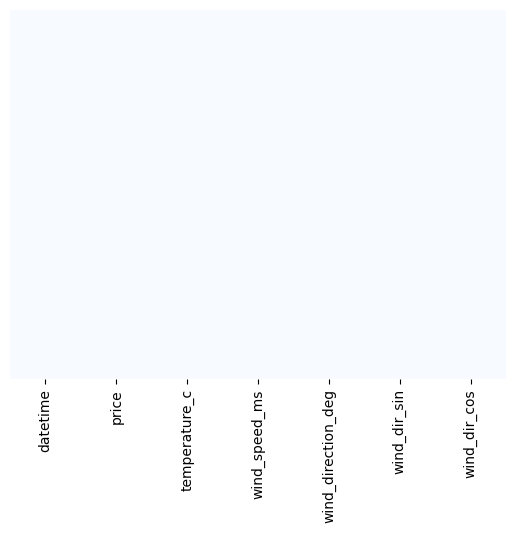

In [21]:
# check for missing values using a heatmap
sns.heatmap(final_df.isnull(), yticklabels=False, cbar=False, cmap='Blues')
plt.show()

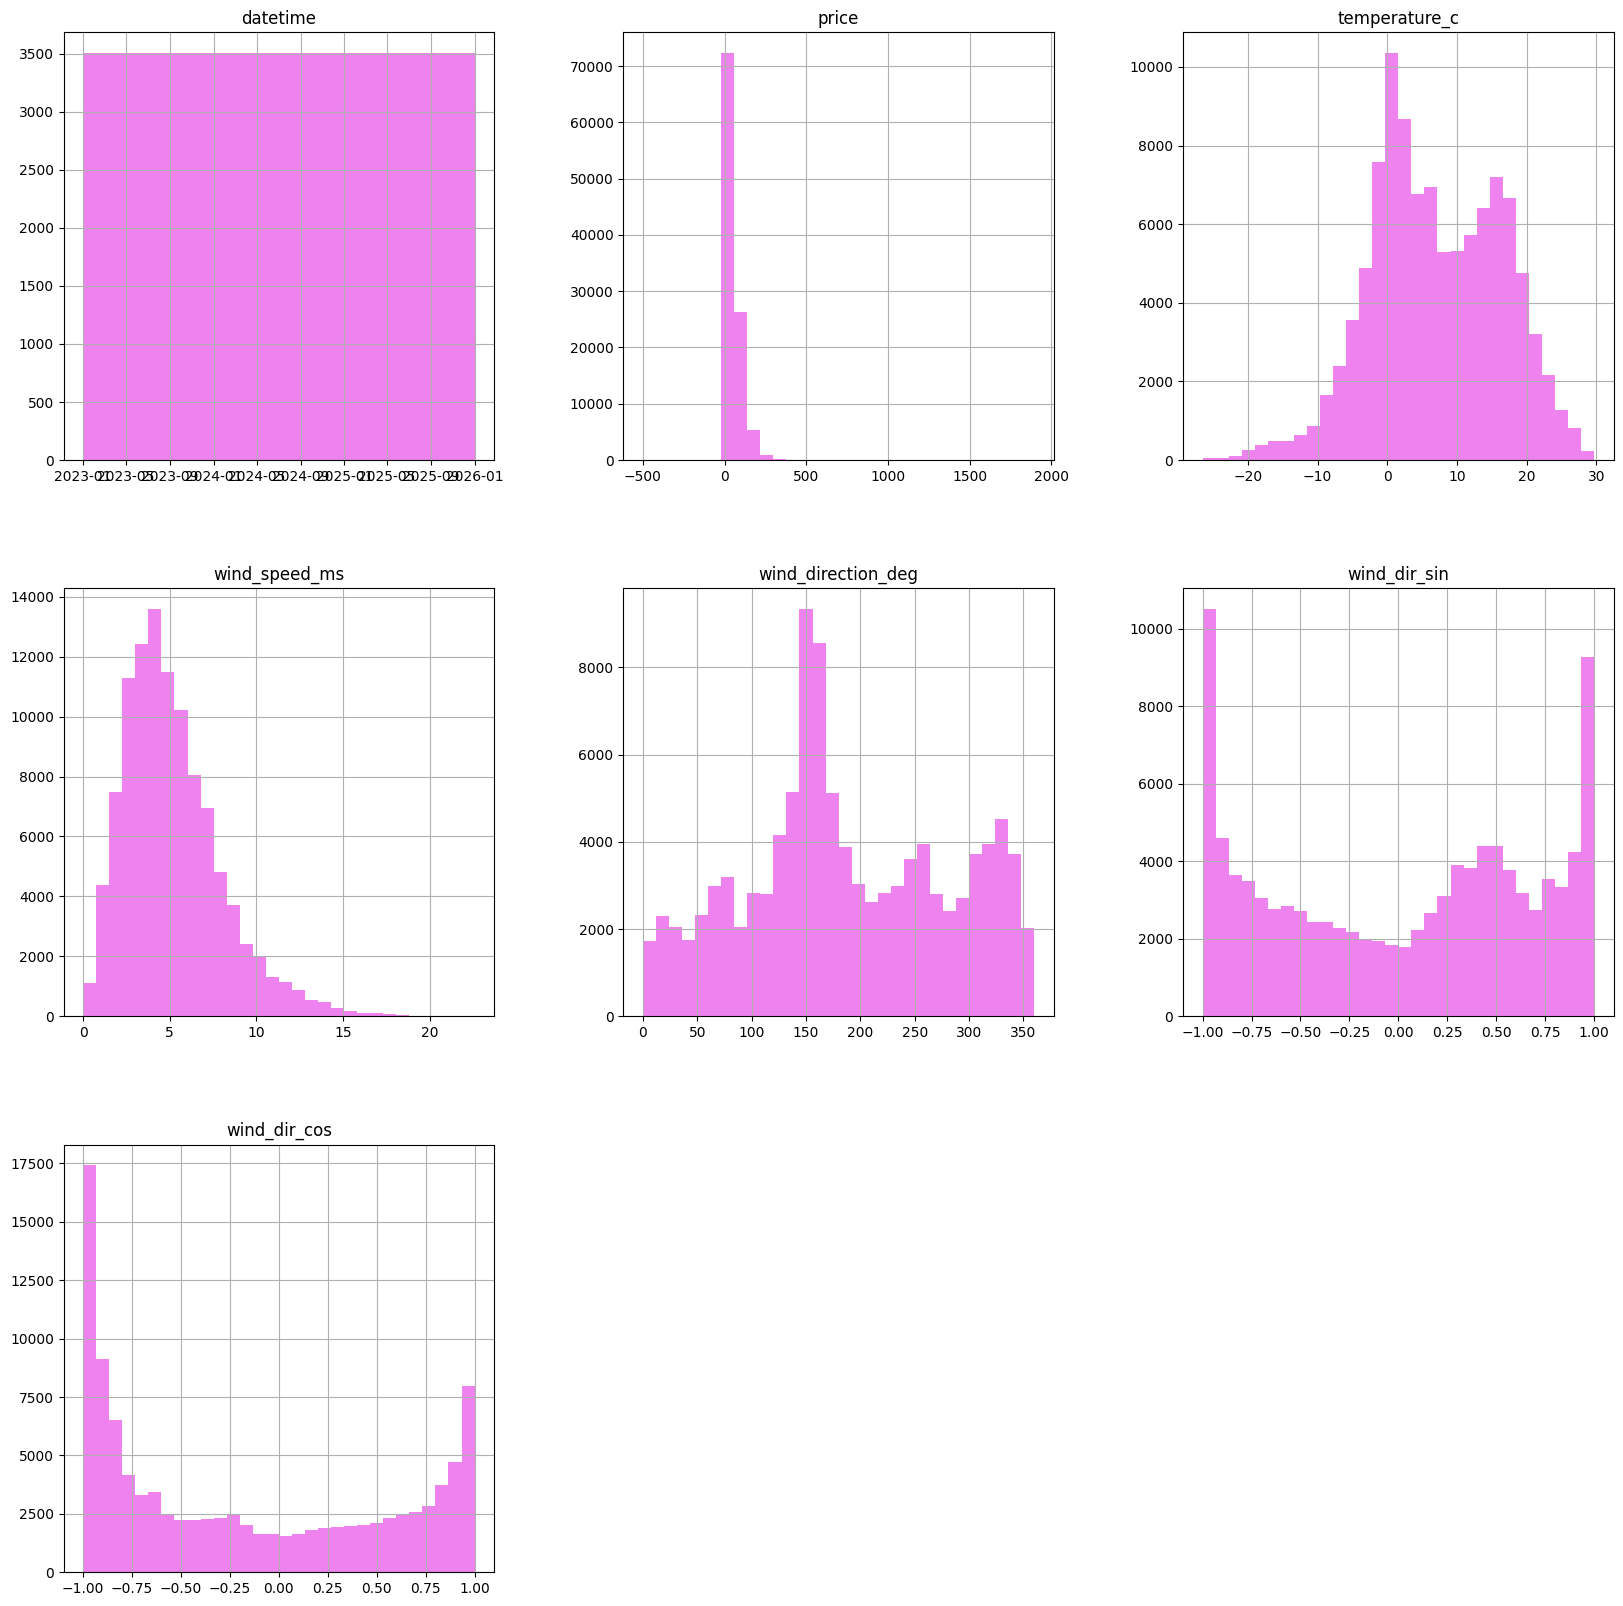

In [22]:
# plot histograms for all numeric columns
final_df.hist(bins=30, figsize=(20, 20), color='violet')
plt.show()

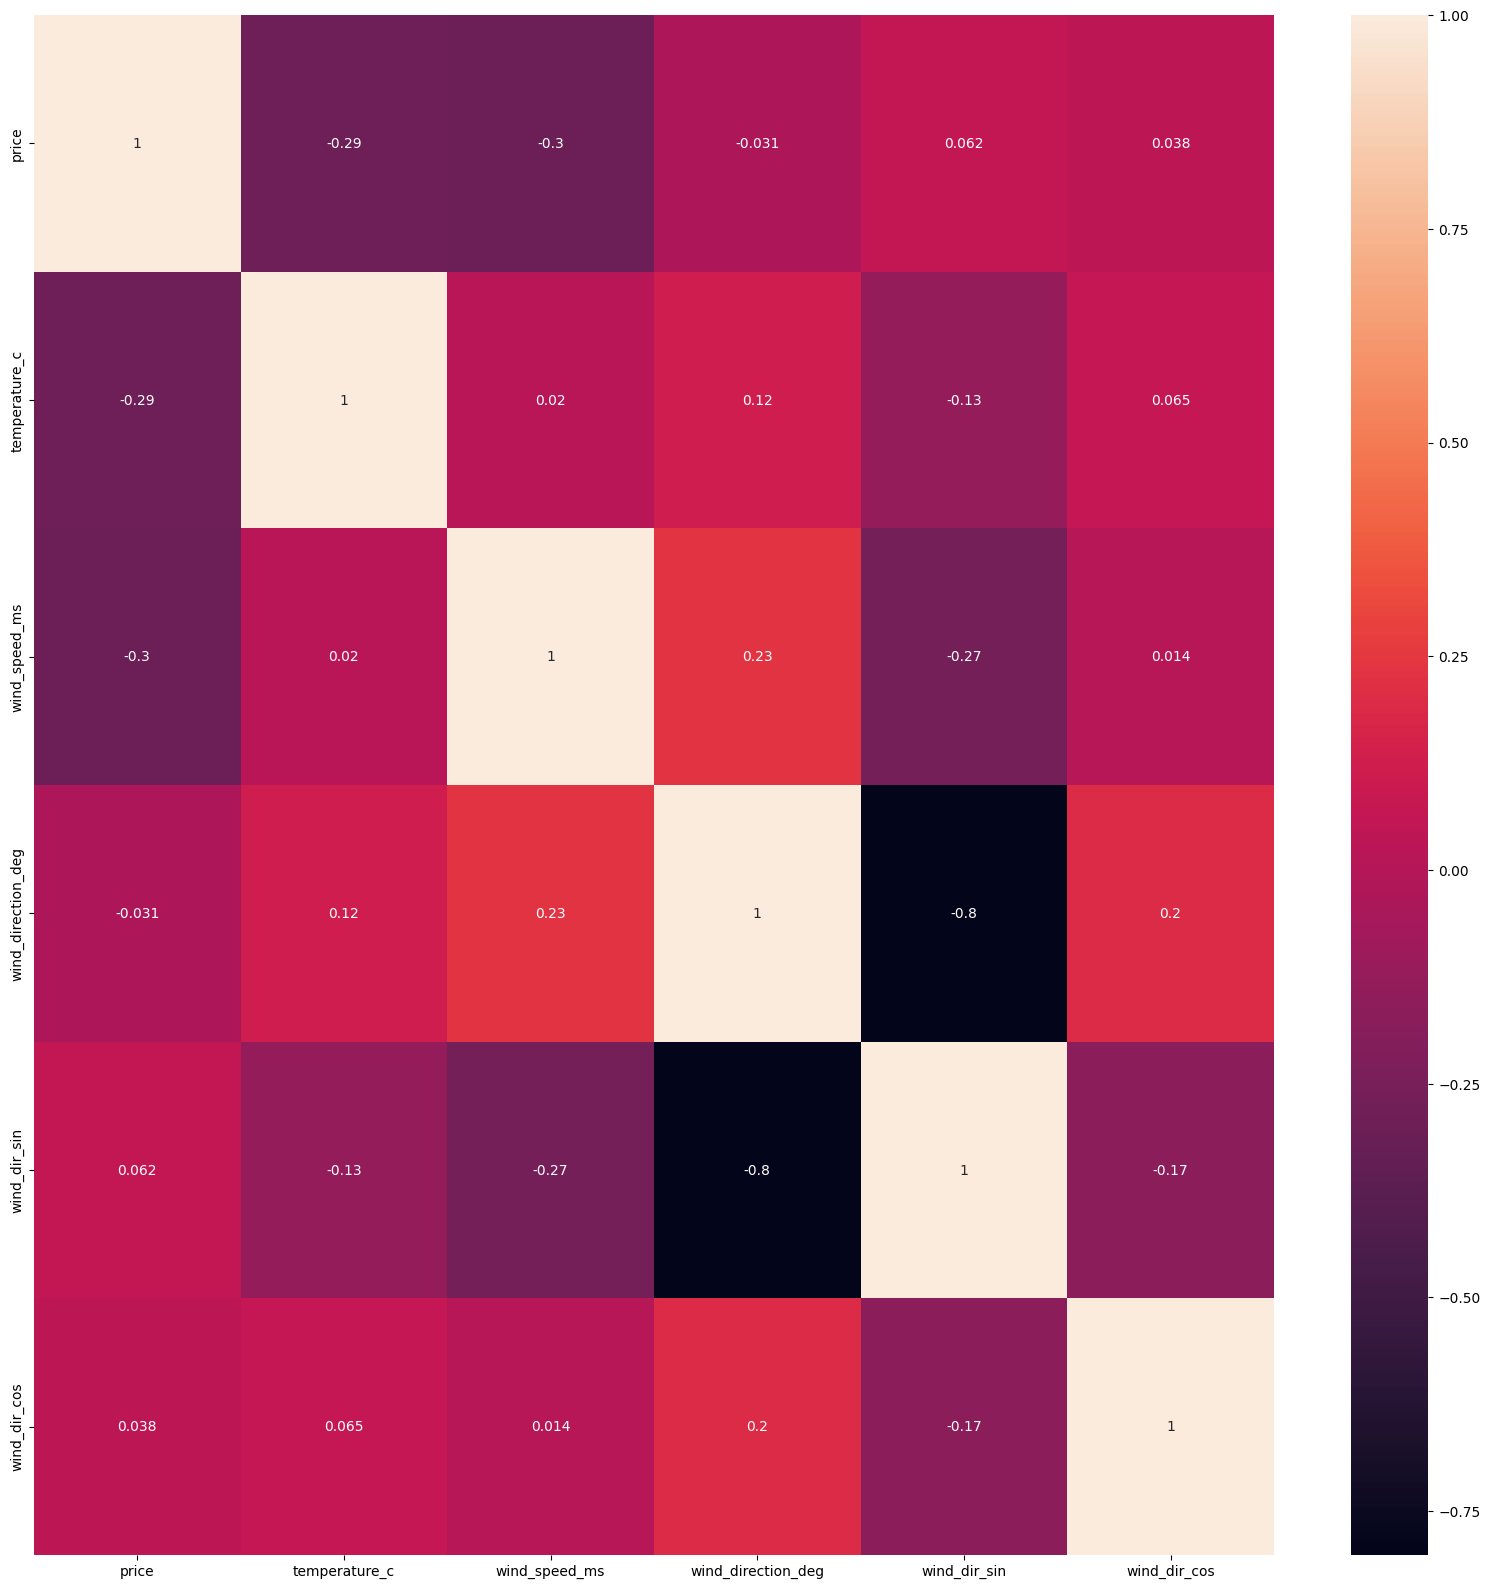

In [23]:
# plot the correlation matrix
plt.figure(figsize=(20, 20))
corr_matrix = final_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
plt.show()